IMPORTS

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
import tqdm
import nltk
import requests
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split, cross_val_score
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from bs4 import BeautifulSoup
from wordcloud import WordCloud, STOPWORDS
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from tensorflow.keras.layers import Conv1D, SimpleRNN, Bidirectional, MaxPooling1D, GlobalMaxPool1D, LSTM, GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import L1L2
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC





NEWS

In [48]:
df=pd.read_csv('../470_project/stockMarket_predict/Combined_News_DJIA.csv')
df.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Elephants extinct by 2020?',b'US humanitarian missions soon in Georgia - i...,"b""Georgia's DDOS came from US sources""","b'Russian convoy heads into Georgia, violating...",b'Israeli defence minister: US against strike ...,b'Gorbachev: We Had No Choice',b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree 

In [49]:
df.shape

(1989, 27)

Yani 1989 row, 27 tane de column var

DJIA TABLE

In [50]:
df2=pd.read_csv('../470_project/stockMarket_predict/upload_DJIA_table.csv')
df2.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688
3,2016-06-28,17190.509766,17409.720703,17190.509766,17409.720703,112190000,17409.720703
4,2016-06-27,17355.210938,17355.210938,17063.080078,17140.240234,138740000,17140.240234


In [51]:
merge = df.merge(df2, how='inner', on='Date')
merge.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top22,Top23,Top24,Top25,Open,High,Low,Close,Volume,Adj Close
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge""",11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo...",11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man...",11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b'Witness: Russian forces head towards Tbilisi...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree to missle defense deal. ...,"b'Will the Russians conquer Tblisi? Bet on it,...",...,b'Taliban wages war on humanitarian aid workers',"b'Russia: World ""can forget about"" Georgia\'s...",b'Darfur rebels accuse Sudan of mounting major...,b'Philippines : Peace Advocate say Muslims nee...,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688


In [52]:
merge.describe()

,Label,Open,High,Low,Close,Volume,Adj Close
count,1989.000000,1989.000000,1989.000000,1989.000000,1989.000000,1.989000e+03,1989.000000
mean,0.535445,13459.116048,13541.303173,13372.931728,13463.032255,1.628110e+08,13463.032255
std,0.498867,3143.281634,3136.271725,3150.420934,3144.006996,9.392343e+07,3144.006996
min,0.000000,6547.009766,6709.609863,6469.950195,6547.049805,8.410000e+06,6547.049805
25%,0.000000,10907.339844,11000.980469,10824.759766,10913.379883,1.000000e+08,10913.379883
50%,1.000000,13022.049805,13088.110352,12953.129883,13025.580078,1.351700e+08,13025.580078
75%,1.000000,16477.699219,16550.070312,16392.769531,16478.410156,1.926000e+08,16478.410156
max,1.000000,18315.060547,18351.359375,18272.560547,18312.390625,6.749200e+08,18312.390625


In [53]:
headline = []
#haberlerin hepsini birlestirdim
for row in range(0, len(merge.index)):
    headline.append(' '.join(str(x) for x in merge.iloc[row, 2:27]))
    
headline[1]

'b\'Why wont America and Nato help us? If they wont help us now, why did we help them in Iraq?\' b\'Bush puts foot down on Georgian conflict\' b"Jewish Georgian minister: Thanks to Israeli training, we\'re fending off Russia " b\'Georgian army flees in disarray as Russians advance - Gori abandoned to Russia without a shot fired\' b"Olympic opening ceremony fireworks \'faked\'" b\'What were the Mossad with fraudulent New Zealand Passports doing in Iraq?\' b\'Russia angered by Israeli military sale to Georgia\' b\'An American citizen living in S.Ossetia blames U.S. and Georgian leaders for the genocide of innocent people\' b\'Welcome To World War IV! Now In High Definition!\' b"Georgia\'s move, a mistake of monumental proportions " b\'Russia presses deeper into Georgia; U.S. says regime change is goal\' b\'Abhinav Bindra wins first ever Individual Olympic Gold Medal for India\' b\' U.S. ship heads for Arctic to define territory\' b\'Drivers in a Jerusalem taxi station threaten to quit ra

In [54]:
clean_headline = []
for head in range(0, len(headline)):
    clean_headline.append(re.sub("b[(')]",'', headline[head]))
    clean_headline[head]=re.sub('b[(")]','', clean_headline[head])    
    clean_headline[head]=re.sub("\'",'', clean_headline[head])

pd.reset_option('max_columns')
merge['Combined_News'] = clean_headline
merge.head()


,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top23,Top24,Top25,Open,High,Low,Close,Volume,Adj Close,Combined_News
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge""",11432.089844,11759.959961,11388.040039,11734.320312,212830000,11734.320312,Georgia downs two Russian warplanes as countri...
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo...",11729.669922,11867.110352,11675.530273,11782.349609,183190000,11782.349609,Why wont America and Nato help us? If they won...
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man...",11781.700195,11782.349609,11601.519531,11642.469727,173590000,11642.469727,Remember that adorable 9-year-old who sang at ...
3,2008-08-13,0,b' U.S. refuses Israel weapons to attack Iran:...,"b""When the president ordered to attack Tskhinv...",b' Israel clears troops who killed Reuters cam...,b'Britain\'s policy of being tough on drugs is...,b'Body of 14 year old found in trunk; Latest (...,b'China has moved 10 *million* quake survivors...,"b""Bush announces Operation Get All Up In Russi...",b'Russian forces sink Georgian ships ',...,b' Quarter of Russians blame U.S. for conflict...,b'Georgian president says US military will ta...,b'2006: Nobel laureate Aleksander Solzhenitsyn...,11632.809570,11633.780273,11453.339844,11532.959961,182550000,11532.959961,U.S. refuses Israel weapons to attack Iran: r...
4,2008-08-14,1,b'All the experts admit that we should legalis...,b'War in South Osetia - 89 pictures made by a ...,b'Swedish wrestler Ara Abrahamian throws away ...,b'Russia exaggerated the death toll in South O...,b'Missile That Killed 9 Inside Pakistan May Ha...,"b""Rushdie Condemns Random House's Refusal to P...",b'Poland and US agree to missle defense deal. ...,"b'Will the Russians conquer Tblisi? Bet on it,...",...,"b'Russia: World ""can forget about"" Georgia\'s...",b'Darfur rebels accuse Sudan of mounting major...,b'Philippines : Peace Advocate say Muslims nee...,11532.070312,11718.280273,11450.889648,11615.929688,159790000,11615.929688,All the experts admit that we should legalise ...


In [55]:
samples = list(merge['Combined_News'][0:20].values)

In [56]:
token={}
for sample in samples:
    for words in sample.split():
        if words not in token:
            token[words] = len(token)+1
            

In [57]:
max_length = 20
result=np.zeros(shape=(len(samples),max_length, max(token.values())+1))
print("Shape of stored results array:", result.shape)
print("Token index of unique words: \n", token)

Shape of stored results array: (20, 20, 2890)
Token index of unique words: 
 {'Georgia': 1, 'downs': 2, 'two': 3, 'Russian': 4, 'warplanes': 5, 'as': 6, 'countries': 7, 'move': 8, 'to': 9, 'brink': 10, 'of': 11, 'war"': 12, 'BREAKING:': 13, 'Musharraf': 14, 'be': 15, 'impeached.': 16, 'Russia': 17, 'Today:': 18, 'Columns': 19, 'troops': 20, 'roll': 21, 'into': 22, 'South': 23, 'Ossetia;': 24, 'footage': 25, 'from': 26, 'fighting': 27, '(YouTube)': 28, 'tanks': 29, 'are': 30, 'moving': 31, 'towards': 32, 'the': 33, 'capital': 34, 'Ossetia,': 35, 'which': 36, 'has': 37, 'reportedly': 38, 'been': 39, 'completely': 40, 'destroyed': 41, 'by': 42, 'Georgian': 43, 'artillery': 44, 'fire': 45, 'Afghan': 46, 'children': 47, 'raped': 48, 'with': 49, 'impunity,': 50, 'U.N.': 51, 'official': 52, 'says': 53, '-': 54, 'this': 55, 'is': 56, 'sick,': 57, 'a': 58, 'three': 59, 'year': 60, 'old': 61, 'was': 62, 'and': 63, 'they': 64, 'do': 65, 'nothing"': 66, '150': 67, 'have': 68, 'entered': 69, 'Osset

In [58]:
for i, sample in enumerate(samples):
    for j, word in list(enumerate(sample.split()))[:max_length]:
        index = token.get(word)
        result[i, j, index] = 1


In [59]:
# one hot encoding using keras tokenizer and pad sequencing
X = merge['Combined_News']
encoder = LabelEncoder()
# y = encoder.fit_transform(merge['Combined_News'])
y=merge['Label']
print("shape of input data: ", X.shape)
print("shape of target variable: ", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

shape of input data:  (1989,)
shape of target variable:  (1989,)


In [60]:
def remove_accented_characters(text):
    text =  unicodedata.normalize('NFKD',text).encode('ascii','ignore').decode('utf-8','ignore')
    return text



def contractions_text(text):
    return contractions.fix(text)

def stop_words(text):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(text)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    filtered_sentence = []
  
    for w in word_tokens:
        
        if w not in stop_words:
            
            filtered_sentence.append(w)
    return filtered_sentence

In [61]:
def preprocessor_engine(text):
    corpus =[]
    for sent in tqdm.tqdm(text):
        sent = remove_accented_characters(sent)
        sent = stop_words(sent)
        corpus.append(sent)
    return corpus

In [39]:

train_data_pro = preprocessor_engine(X_train)


100%|██████████| 1591/1591 [00:01<00:00, 1084.03it/s]


In [40]:
test_data_pro = preprocessor_engine(X_test)

100%|██████████| 398/398 [00:00<00:00, 1081.21it/s]


In [41]:
articles_list=[]
cat_array = train_data_pro
for i in range(len(cat_array)):#train datamız train_data_pro
    articles_list.append(cat_array[i])

In [42]:
wc = WordCloud(max_words=10000000,
               min_font_size=10,
               height=1000,
                width=2000,
                background_color='white',
                contour_color='black',
                colormap='viridis',
                repeat=True,
                stopwords=STOPWORDS)

tokenizer = Tokenizer(oov_token='<UNK>')
tokenizer.fit_on_texts(train_data_pro)
#buradan sonra datayı kendi modelinle eğiteceksin
#buraya feature extraction yapacağım




In [43]:
#buraya feature extraction yapacağım
# Feature Extraction - Metin verisi ön işleme ve özellik çıkarımı

# NLTK veri setlerini indir (ilk kullanım için) 
nltk.download('stopwords')
nltk.download('punkt')

# Stopwords listesi
stop_words = set(stopwords.words('english'))

# Metin temizleme fonksiyonları
def remove_punctuation(text):
    text = re.sub(r'[^\w\s]', '', text)  # Noktalama işaretlerini kaldırır
    return text

def remove_stopwords(text):
    words = nltk.word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Metin verisinde ön işleme adımlarını uygulama
X_train_cleaned = X_train.apply(remove_punctuation).apply(remove_stopwords)
X_test_cleaned = X_test.apply(remove_punctuation).apply(remove_stopwords)

# Özellik Çıkarma - TF-IDF Vektörizasyon
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_nb = vectorizer.fit_transform(X_train_cleaned)
X_test_nb = vectorizer.transform(X_test_cleaned)
#_nb feature extraction uygulanmış veri


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/emirhanbuyukoner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/emirhanbuyukoner/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


         Model  Accuracy  Precision    Recall  F1-Score
0  Naive Bayes  0.520101   0.472758  0.520101  0.451866


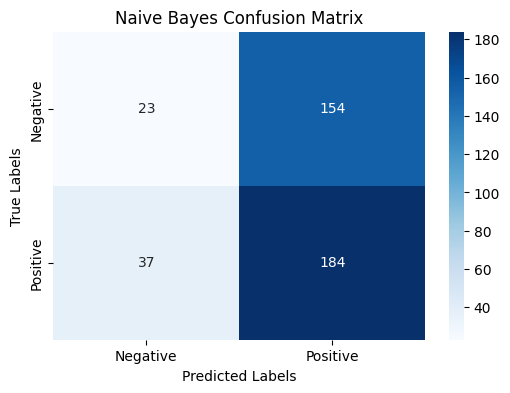

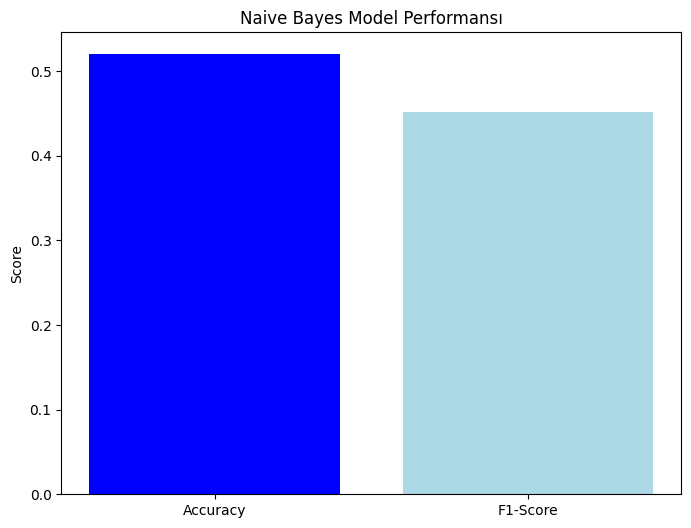

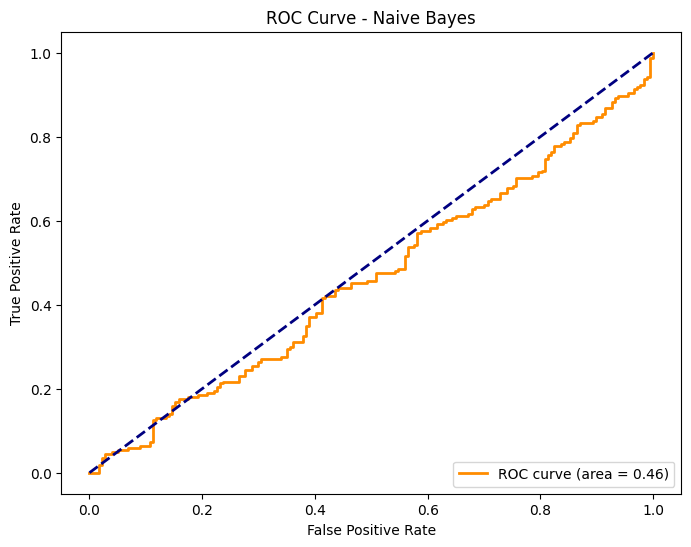

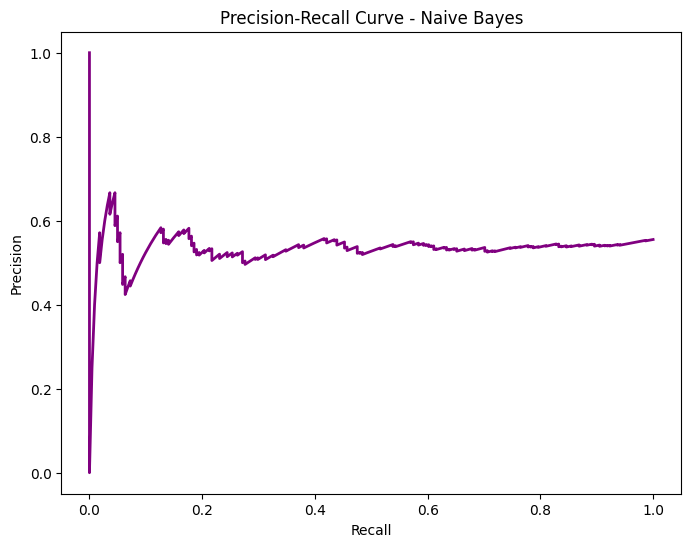

/var/folders/dp/7k645f450ts9ly23q1k60wxm0000gn/T/ipykernel_6802/382518939.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features_df, palette='viridis')


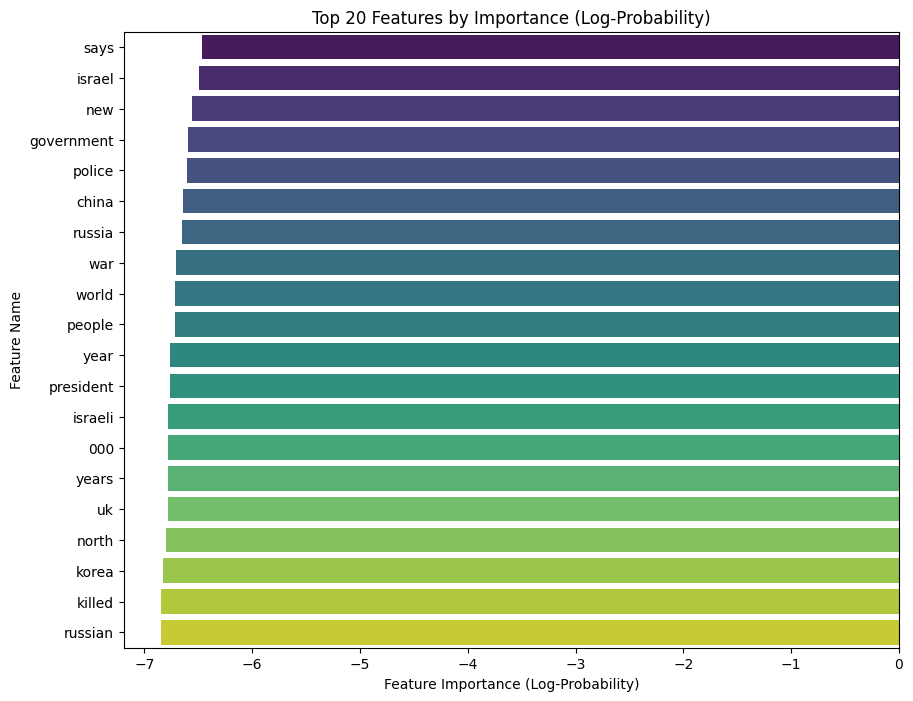

In [44]:
# Naive Bayes


# Naive Bayes için metin verisini vektörize etme
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_nb_wfe = vectorizer.fit_transform(X_train)
X_test_nb_wfe = vectorizer.transform(X_test)

# Naive Bayes modelini eğitme
nb_model = MultinomialNB()
nb_model.fit(X_train_nb_wfe, y_train)

# Naive Bayes modelini değerlendirme
y_pred_nb = nb_model.predict(X_test_nb_wfe)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

# Classification Report ve Confusion Matrix
nb_classification_report = classification_report(y_test, y_pred_nb, output_dict=True)
nb_conf_matrix = confusion_matrix(y_test, y_pred_nb)

# Sonuçları DataFrame olarak hazırlama
results = pd.DataFrame({
    "Model": ["Naive Bayes"],
    "Accuracy": [nb_accuracy],
    "Precision": [nb_classification_report['weighted avg']['precision']],
    "Recall": [nb_classification_report['weighted avg']['recall']],
    "F1-Score": [nb_classification_report['weighted avg']['f1-score']]
})

print(results)

# Confusion Matrix'i görselleştirme
plt.figure(figsize=(6, 4))
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Naive Bayes için Accuracy ve F1-Score Grafiği
plt.figure(figsize=(8, 6))
plt.bar(['Accuracy', 'F1-Score'], [nb_accuracy, nb_classification_report['weighted avg']['f1-score']], color=['blue', 'lightblue'])
plt.title('Naive Bayes Model Performansı')
plt.ylabel('Score')
plt.show()

# 1. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, nb_model.predict_proba(X_test_nb_wfe)[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.show()

# 2. Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, nb_model.predict_proba(X_test_nb_wfe)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Naive Bayes')
plt.show()

# 3. Top N Features
# En önemli özellikleri gösterme
feature_names = vectorizer.get_feature_names_out()
feature_importance = nb_model.feature_log_prob_[1]  # Pozitif sınıfın log-olasılıkları
top_n = 20  # Gösterilecek en önemli özellik sayısı

top_n_features = sorted(zip(feature_importance, feature_names), reverse=True)[:top_n]
top_features_df = pd.DataFrame(top_n_features, columns=['Importance', 'Feature'])

# En Önemli N Özellik Grafiği
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features_df, palette='viridis')
plt.title(f'Top {top_n} Features by Importance (Log-Probability)')
plt.xlabel('Feature Importance (Log-Probability)')
plt.ylabel('Feature Name')
plt.show()


         Model  Accuracy  Precision    Recall  F1-Score
0  Naive Bayes  0.520101   0.472758  0.520101  0.451866


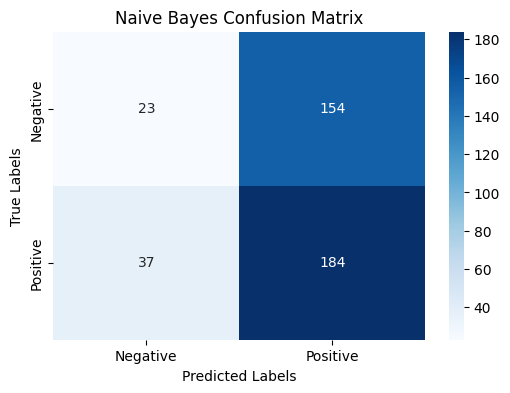

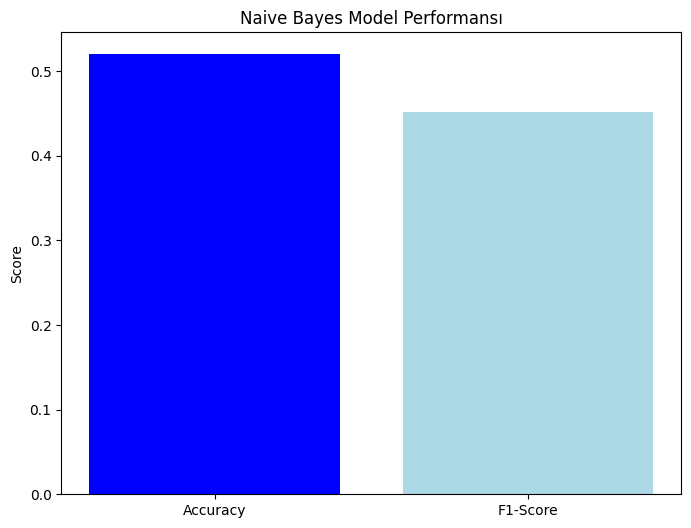

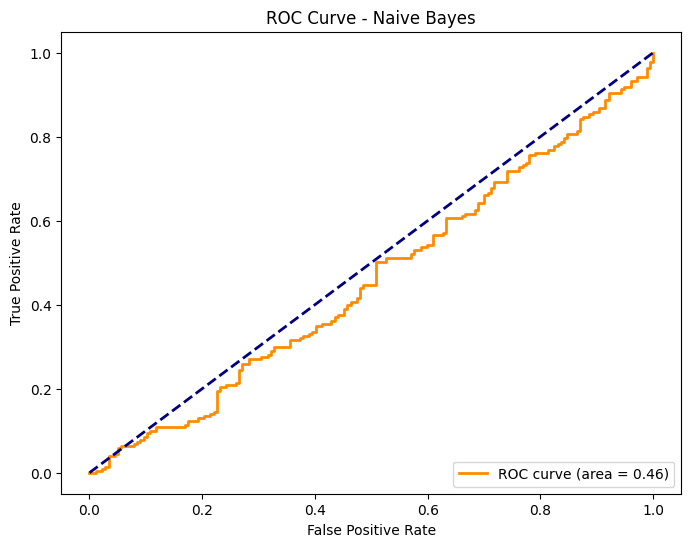

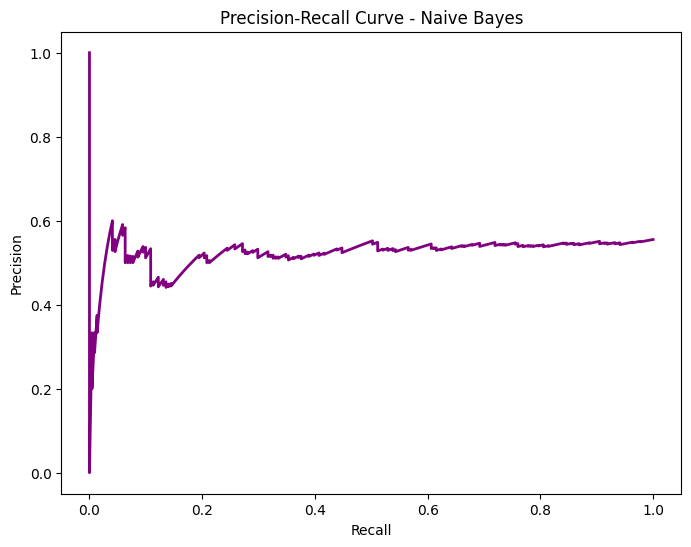

/var/folders/dp/7k645f450ts9ly23q1k60wxm0000gn/T/ipykernel_6802/1126719545.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features_df, palette='viridis')


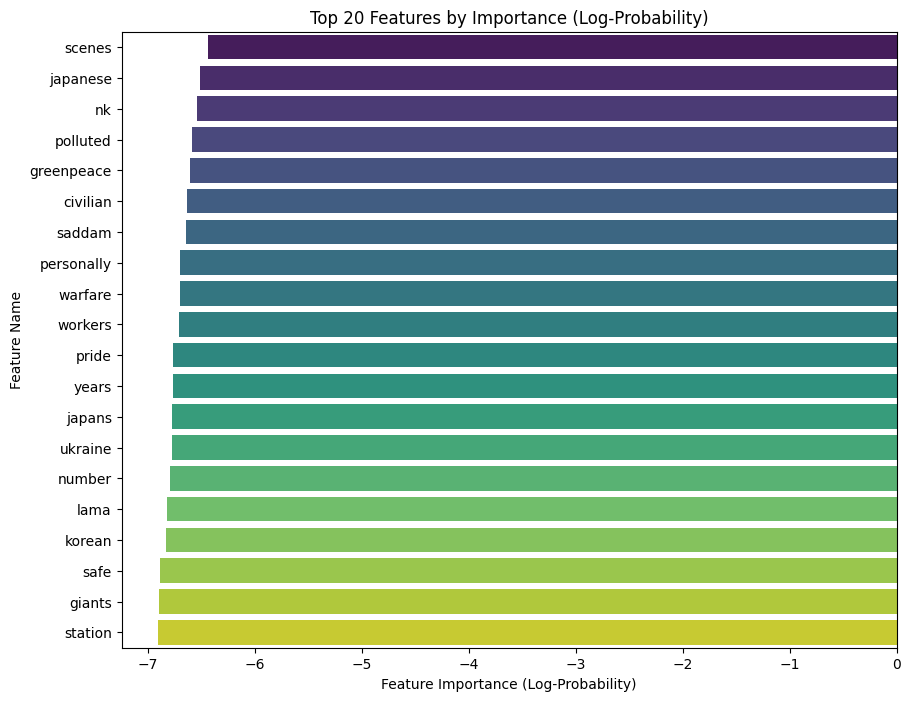

In [45]:
# Naive Bayes ilk feature extraction türü sonrası

nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_classification_report = classification_report(y_test, y_pred_nb, output_dict=True)
nb_conf_matrix = confusion_matrix(y_test, y_pred_nb)

results = pd.DataFrame({
    "Model": ["Naive Bayes"],
    "Accuracy": [nb_accuracy],
    "Precision": [nb_classification_report['weighted avg']['precision']],
    "Recall": [nb_classification_report['weighted avg']['recall']],
    "F1-Score": [nb_classification_report['weighted avg']['f1-score']]
})

print(results)

plt.figure(figsize=(6, 4))
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(['Accuracy', 'F1-Score'], [nb_accuracy, nb_classification_report['weighted avg']['f1-score']], color=['blue', 'lightblue'])
plt.title('Naive Bayes Model Performansı')
plt.ylabel('Score')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, nb_model.predict_proba(X_test_nb)[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.show()

precision, recall, thresholds_pr = precision_recall_curve(y_test, nb_model.predict_proba(X_test_nb)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Naive Bayes')
plt.show()

feature_names = vectorizer.get_feature_names_out()
feature_importance = nb_model.feature_log_prob_[1]  # Pozitif sınıfın log-olasılıkları
top_n = 20  # Gösterilecek en önemli özellik sayısı

top_n_features = sorted(zip(feature_importance, feature_names), reverse=True)[:top_n]
top_features_df = pd.DataFrame(top_n_features, columns=['Importance', 'Feature'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features_df, palette='viridis')
plt.title(f'Top {top_n} Features by Importance (Log-Probability)')
plt.xlabel('Feature Importance (Log-Probability)')
plt.ylabel('Feature Name')
plt.show()


  Model  Accuracy  Precision    Recall  F1-Score
0   SVM  0.502513   0.491729  0.502513  0.493087


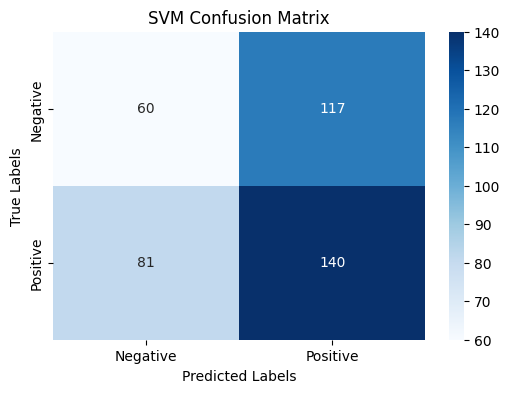

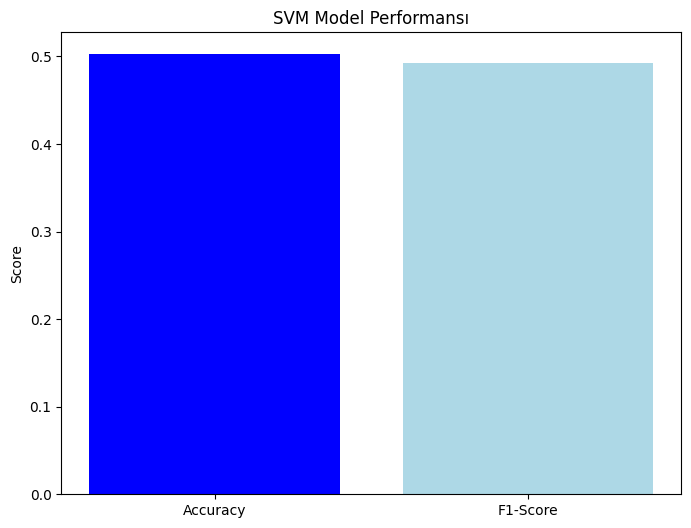

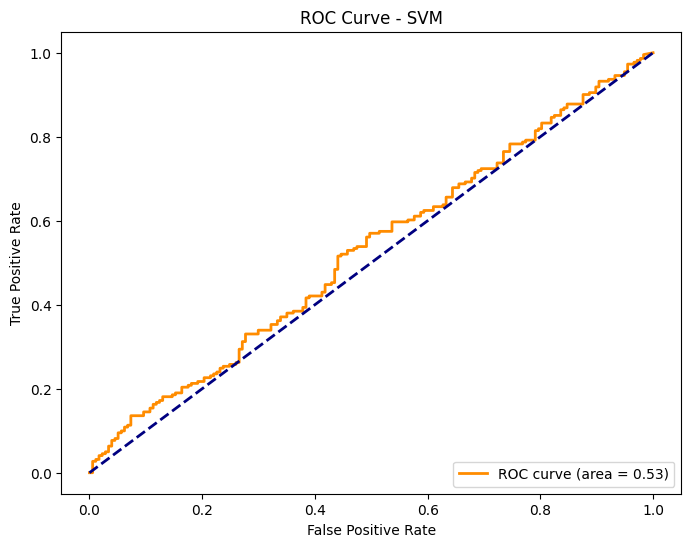

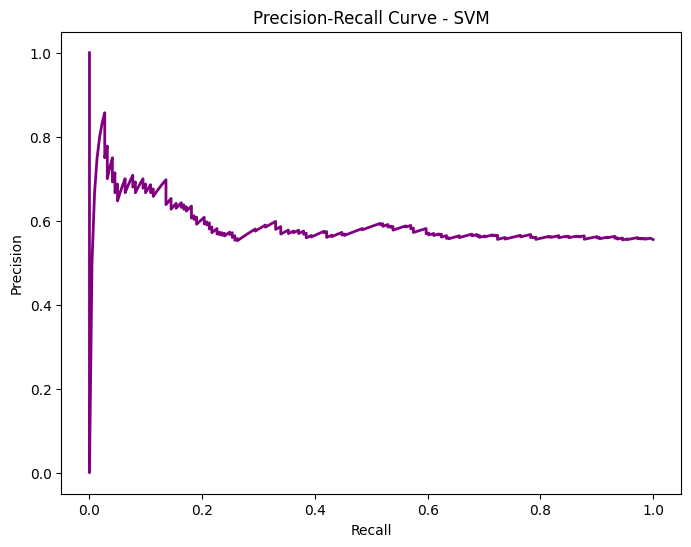

/var/folders/dp/7k645f450ts9ly23q1k60wxm0000gn/T/ipykernel_6802/1818956739.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features_df, palette='viridis')


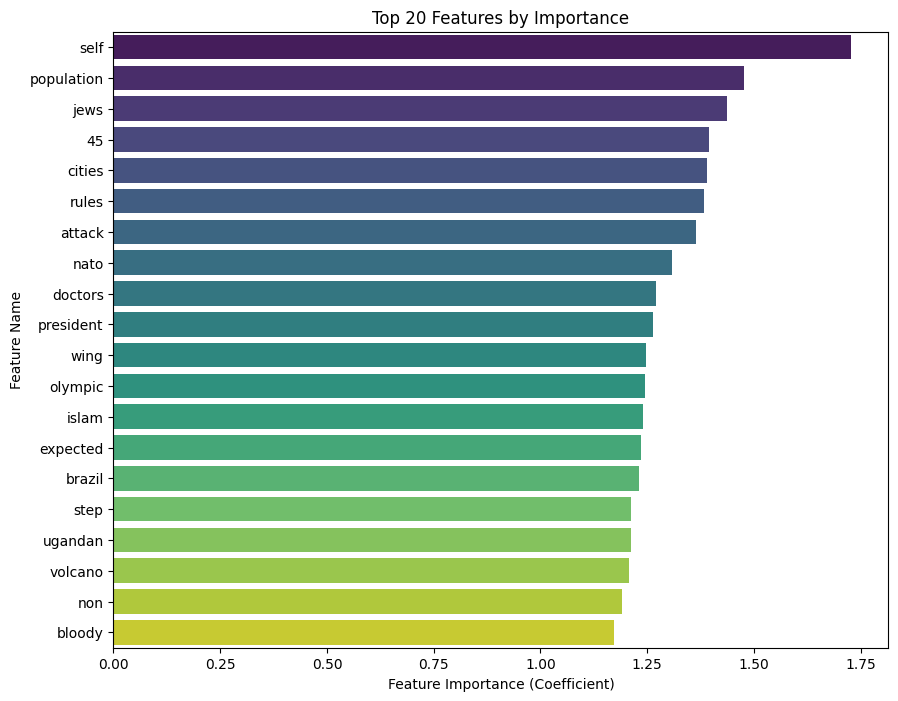

In [46]:
# SVM ilk feature extraction türü sonrası
# üstteki kısımların aynısı
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_svm = vectorizer.fit_transform(X_train)
X_test_svm = vectorizer.transform(X_test)

svm_model = SVC(kernel='linear', probability=True)  # Linear kernel kullanılıyor, ROC için probability=True
svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_classification_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)

results_svm = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [svm_accuracy],
    "Precision": [svm_classification_report['weighted avg']['precision']],
    "Recall": [svm_classification_report['weighted avg']['recall']],
    "F1-Score": [svm_classification_report['weighted avg']['f1-score']]
})

print(results_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("SVM Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(['Accuracy', 'F1-Score'], [svm_accuracy, svm_classification_report['weighted avg']['f1-score']], color=['blue', 'lightblue'])
plt.title('SVM Model Performansı')
plt.ylabel('Score')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, svm_model.predict_proba(X_test_svm)[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc="lower right")
plt.show()

precision, recall, thresholds_pr = precision_recall_curve(y_test, svm_model.predict_proba(X_test_svm)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM')
plt.show()

feature_names = vectorizer.get_feature_names_out()
feature_importance = svm_model.coef_.toarray()[0]  # Linear kernel kullanıldığı için koefisiyentleri kullanabiliriz
top_n = 20  # Gösterilecek en önemli özellik sayısı

top_n_features = sorted(zip(feature_importance, feature_names), reverse=True)[:top_n]
top_features_df = pd.DataFrame(top_n_features, columns=['Importance', 'Feature'])

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features_df, palette='viridis')
plt.title(f'Top {top_n} Features by Importance')
plt.xlabel('Feature Importance (Coefficient)')
plt.ylabel('Feature Name')
plt.show()
